<a href="https://colab.research.google.com/github/rohitash1334/Bihar_District_Development_Index/blob/main/Bihar_District_Development_Index_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏛️ Bihar District Development Index (BDDI)
### A Multi-Dimensional Machine Learning & Data Analytics Project

---

**Author:** Rohitashv | B.E. ECE, RVCE Bengaluru  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn · Plotly  
**Domain:** Public Policy Analytics | Geospatial Development Studies

---

## 📌 Objective
Construct a composite **Bihar District Development Index (BDDI)** for all **38 districts** using 10 multi-dimensional socio-economic indicators. Apply unsupervised machine learning (K-Means clustering + PCA) to identify development clusters and regional disparities.

## 📊 Indicators Used
| # | Indicator | Weight | Source |
|---|---|---|---|
| 1 | Per Capita Income | 15% | Bihar Economic Survey |
| 2 | Literacy Rate | 14% | Census 2011 |
| 3 | Health Infrastructure Index | 13% | NHM Bihar |
| 4 | Electrification Rate | 11% | DDUGJY / Census |
| 5 | Road Connectivity | 10% | PMGSY / State PWD |
| 6 | Safe Water Access | 10% | NITI Aayog SDG Index |
| 7 | Agricultural Productivity | 9% | Agri Census |
| 8 | Sex Ratio | 7% | Census 2011 |
| 9 | Urbanization Rate | 7% | Census 2011 |
| 10 | Safety Index | 4% | NCRB Bihar (inverse) |

---
## 📦 Step 0: Install & Import Libraries

In [1]:
# Install any missing libraries (Colab already has most)
!pip install plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📁 Step 1: Create the Dataset
District-level data for all 38 Bihar districts based on Census 2011, Bihar Economic Survey, NITI Aayog reports, and NHM Bihar. Values are approximate and compiled for educational/portfolio purposes.

In [2]:
districts_data = {
    'District': [
        'Patna', 'Gaya', 'Bhagalpur', 'Muzaffarpur', 'Darbhanga',
        'Purnia', 'Araria', 'Sitamarhi', 'Madhubani', 'Supaul',
        'Saharsa', 'Madhepura', 'Kishanganj', 'Katihar', 'East Champaran',
        'West Champaran', 'Sheohar', 'Gopalganj', 'Siwan', 'Saran',
        'Vaishali', 'Nalanda', 'Nawada', 'Aurangabad', 'Jehanabad',
        'Arwal', 'Rohtas', 'Buxar', 'Kaimur', 'Bhojpur',
        'Lakhisarai', 'Sheikhpura', 'Munger', 'Jamui', 'Banka',
        'Begusarai', 'Samastipur', 'Khagaria'
    ],
    # Literacy Rate (%)
    'Literacy_Rate': [
        70.68, 63.67, 63.29, 61.89, 55.68,
        51.08, 40.34, 49.29, 52.56, 53.74,
        55.36, 48.19, 45.48, 52.24, 57.72,
        59.28, 44.63, 65.47, 69.53, 67.27,
        66.59, 64.43, 59.76, 61.32, 63.45,
        58.90, 73.37, 70.10, 69.30, 70.52,
        63.85, 63.03, 67.48, 56.11, 55.50,
        63.85, 60.08, 56.79
    ],
    # Sex Ratio (females per 1000 males)
    'Sex_Ratio': [
        897, 935, 882, 900, 911,
        921, 936, 899, 926, 951,
        920, 907, 961, 916, 909,
        921, 887, 1015, 988, 954,
        895, 922, 936, 925, 929,
        940, 915, 898, 919, 910,
        911, 952, 876, 930, 917,
        895, 910, 883
    ],
    # Per Capita Income proxy (INR thousands/year)
    'Per_Capita_Income_K': [
        48.2, 22.1, 28.4, 25.8, 19.6,
        21.3, 16.8, 17.5, 18.2, 20.1,
        21.8, 18.9, 17.2, 22.6, 20.4,
        21.9, 15.3, 24.7, 26.1, 25.3,
        27.8, 29.4, 22.7, 24.1, 26.3,
        21.5, 31.8, 30.2, 29.6, 28.9,
        25.6, 23.4, 28.7, 19.8, 20.3,
        32.4, 24.5, 19.7
    ],
    # Electrification Rate (% households)
    'Electrification_Pct': [
        89.4, 67.3, 71.2, 65.8, 54.3,
        55.6, 40.2, 47.8, 51.3, 53.7,
        55.9, 48.3, 42.1, 54.7, 58.2,
        60.1, 38.5, 63.4, 68.7, 66.2,
        69.1, 70.5, 59.8, 61.3, 64.2,
        57.8, 74.3, 72.1, 70.8, 71.4,
        64.7, 62.3, 69.8, 52.4, 53.1,
        74.8, 62.6, 51.3
    ],
    # Road Connectivity Index (0-100)
    'Road_Connectivity': [
        87.3, 61.2, 66.4, 63.1, 55.7,
        52.3, 38.9, 46.2, 49.8, 51.4,
        53.7, 46.9, 40.3, 52.8, 56.4,
        58.1, 36.7, 61.8, 66.3, 64.2,
        67.4, 68.9, 58.3, 59.7, 62.5,
        56.1, 72.6, 70.4, 69.1, 70.2,
        63.4, 60.8, 68.3, 50.7, 51.2,
        73.2, 61.5, 49.8
    ],
    # Health Infrastructure Index (0-100)
    'Health_Index': [
        82.4, 58.3, 61.7, 57.2, 47.8,
        49.6, 35.4, 42.3, 45.1, 47.9,
        49.3, 43.1, 37.8, 48.4, 51.3,
        53.2, 33.2, 56.7, 60.1, 58.4,
        61.8, 63.2, 52.7, 54.3, 57.1,
        50.8, 66.8, 64.5, 63.2, 64.7,
        57.6, 55.3, 62.4, 46.1, 46.8,
        67.3, 56.2, 45.6
    ],
    # Safe Water Access (% households)
    'Safe_Water_Pct': [
        88.2, 71.4, 74.3, 69.8, 62.3,
        63.7, 50.2, 57.4, 60.8, 62.9,
        64.3, 57.8, 52.4, 63.2, 66.7,
        68.4, 48.3, 70.2, 74.8, 72.6,
        75.3, 76.8, 65.9, 67.4, 70.1,
        63.8, 79.4, 77.2, 75.9, 76.7,
        70.3, 68.1, 73.9, 58.7, 59.3,
        79.8, 70.0, 59.1
    ],
    # Agriculture Productivity Index (0-100)
    'Agri_Productivity': [
        55.3, 62.1, 58.4, 65.7, 70.2,
        67.8, 59.3, 72.4, 68.9, 63.5,
        61.2, 64.7, 55.8, 66.3, 71.5,
        69.8, 73.4, 68.2, 66.7, 70.1,
        69.4, 67.8, 63.2, 58.7, 61.4,
        60.8, 64.3, 67.9, 70.4, 66.8,
        62.3, 59.7, 57.4, 61.2, 63.8,
        66.4, 71.2, 68.5
    ],
    # Urbanization Rate (%)
    'Urbanization_Pct': [
        43.1, 22.4, 25.7, 19.8, 12.3,
        14.6,  8.4,  9.1, 10.2, 11.8,
        12.7,  9.6,  7.8, 13.2, 11.4,
        12.1,  6.3, 14.7, 16.2, 15.4,
        17.8, 18.3, 13.6, 14.9, 16.7,
        12.2, 19.8, 18.1, 17.3, 17.8,
        15.2, 13.7, 18.4, 10.2, 10.8,
        21.3, 14.8, 10.1
    ],
    # Safety Index (lower crime = higher score, 0-100)
    'Safety_Index': [
        52.3, 48.7, 55.2, 56.8, 61.3,
        59.7, 64.2, 65.8, 63.4, 66.1,
        64.8, 62.3, 67.9, 60.4, 62.7,
        63.9, 70.2, 66.4, 67.8, 65.3,
        63.7, 62.1, 58.9, 57.4, 60.2,
        63.8, 58.3, 56.7, 61.4, 59.8,
        63.2, 65.8, 57.6, 64.3, 66.7,
        58.2, 61.7, 64.9
    ],
}

df = pd.DataFrame(districts_data)

# Add Region
north_bihar = ['Muzaffarpur','Darbhanga','Sitamarhi','Madhubani','Supaul','Saharsa',
               'Madhepura','Sheohar','East Champaran','West Champaran','Gopalganj',
               'Siwan','Saran','Vaishali','Samastipur','Khagaria']
south_bihar = ['Gaya','Nawada','Aurangabad','Jehanabad','Arwal',
               'Rohtas','Buxar','Kaimur','Bhojpur','Nalanda']
east_bihar  = ['Bhagalpur','Purnia','Araria','Kishanganj','Katihar',
               'Lakhisarai','Sheikhpura','Munger','Jamui','Banka','Begusarai']

def get_region(d):
    if d in north_bihar: return 'North Bihar'
    elif d in south_bihar: return 'South Bihar'
    elif d in east_bihar: return 'East Bihar'
    else: return 'Central Bihar'

df['Region'] = df['District'].apply(get_region)

print(f'Dataset Shape: {df.shape}')
print(f'Districts: {df["District"].nunique()}')
print(f'Regions: {df["Region"].value_counts().to_dict()}')
df.head()

Dataset Shape: (38, 12)
Districts: 38
Regions: {'North Bihar': 16, 'East Bihar': 11, 'South Bihar': 10, 'Central Bihar': 1}


,District,Literacy_Rate,Sex_Ratio,Per_Capita_Income_K,Electrification_Pct,Road_Connectivity,Health_Index,Safe_Water_Pct,Agri_Productivity,Urbanization_Pct,Safety_Index,Region
0,Patna,70.68,897,48.2,89.4,87.3,82.4,88.2,55.3,43.1,52.3,Central Bihar
1,Gaya,63.67,935,22.1,67.3,61.2,58.3,71.4,62.1,22.4,48.7,South Bihar
2,Bhagalpur,63.29,882,28.4,71.2,66.4,61.7,74.3,58.4,25.7,55.2,East Bihar
3,Muzaffarpur,61.89,900,25.8,65.8,63.1,57.2,69.8,65.7,19.8,56.8,North Bihar
4,Darbhanga,55.68,911,19.6,54.3,55.7,47.8,62.3,70.2,12.3,61.3,North Bihar


---
## 🔍 Step 2: Exploratory Data Analysis (EDA)

In [3]:
# Summary Statistics
INDICATORS = [
    'Literacy_Rate', 'Sex_Ratio', 'Per_Capita_Income_K',
    'Electrification_Pct', 'Road_Connectivity', 'Health_Index',
    'Safe_Water_Pct', 'Agri_Productivity', 'Urbanization_Pct', 'Safety_Index'
]

print('=== Descriptive Statistics ===')
df[INDICATORS].describe().round(2)

=== Descriptive Statistics ===


,Literacy_Rate,Sex_Ratio,Per_Capita_Income_K,Electrification_Pct,Road_Connectivity,Health_Index,Safe_Water_Pct,Agri_Productivity,Urbanization_Pct,Safety_Index
count,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00,38.00
mean,59.78,921.03,24.18,60.92,59.04,54.09,67.56,65.07,15.21,61.84
std,8.02,28.22,5.96,10.64,10.48,9.84,8.69,4.84,6.33,4.47
min,40.34,876.00,15.30,38.50,36.70,33.20,48.30,55.30,6.30,48.70
25%,55.40,901.75,20.15,53.85,51.62,47.82,62.45,61.25,11.50,59.10
50%,60.70,918.00,23.05,61.80,60.25,54.80,68.25,66.00,14.65,62.50
75%,65.21,933.75,27.42,69.00,66.38,61.30,74.20,68.80,17.80,64.88
max,73.37,1015.00,48.20,89.40,87.30,82.40,88.20,73.40,43.10,70.20


In [4]:
# Missing values check
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing Values:
District               0
Literacy_Rate          0
Sex_Ratio              0
Per_Capita_Income_K    0
Electrification_Pct    0
Road_Connectivity      0
Health_Index           0
Safe_Water_Pct         0
Agri_Productivity      0
Urbanization_Pct       0
Safety_Index           0
Region                 0
dtype: int64

Total missing: 0


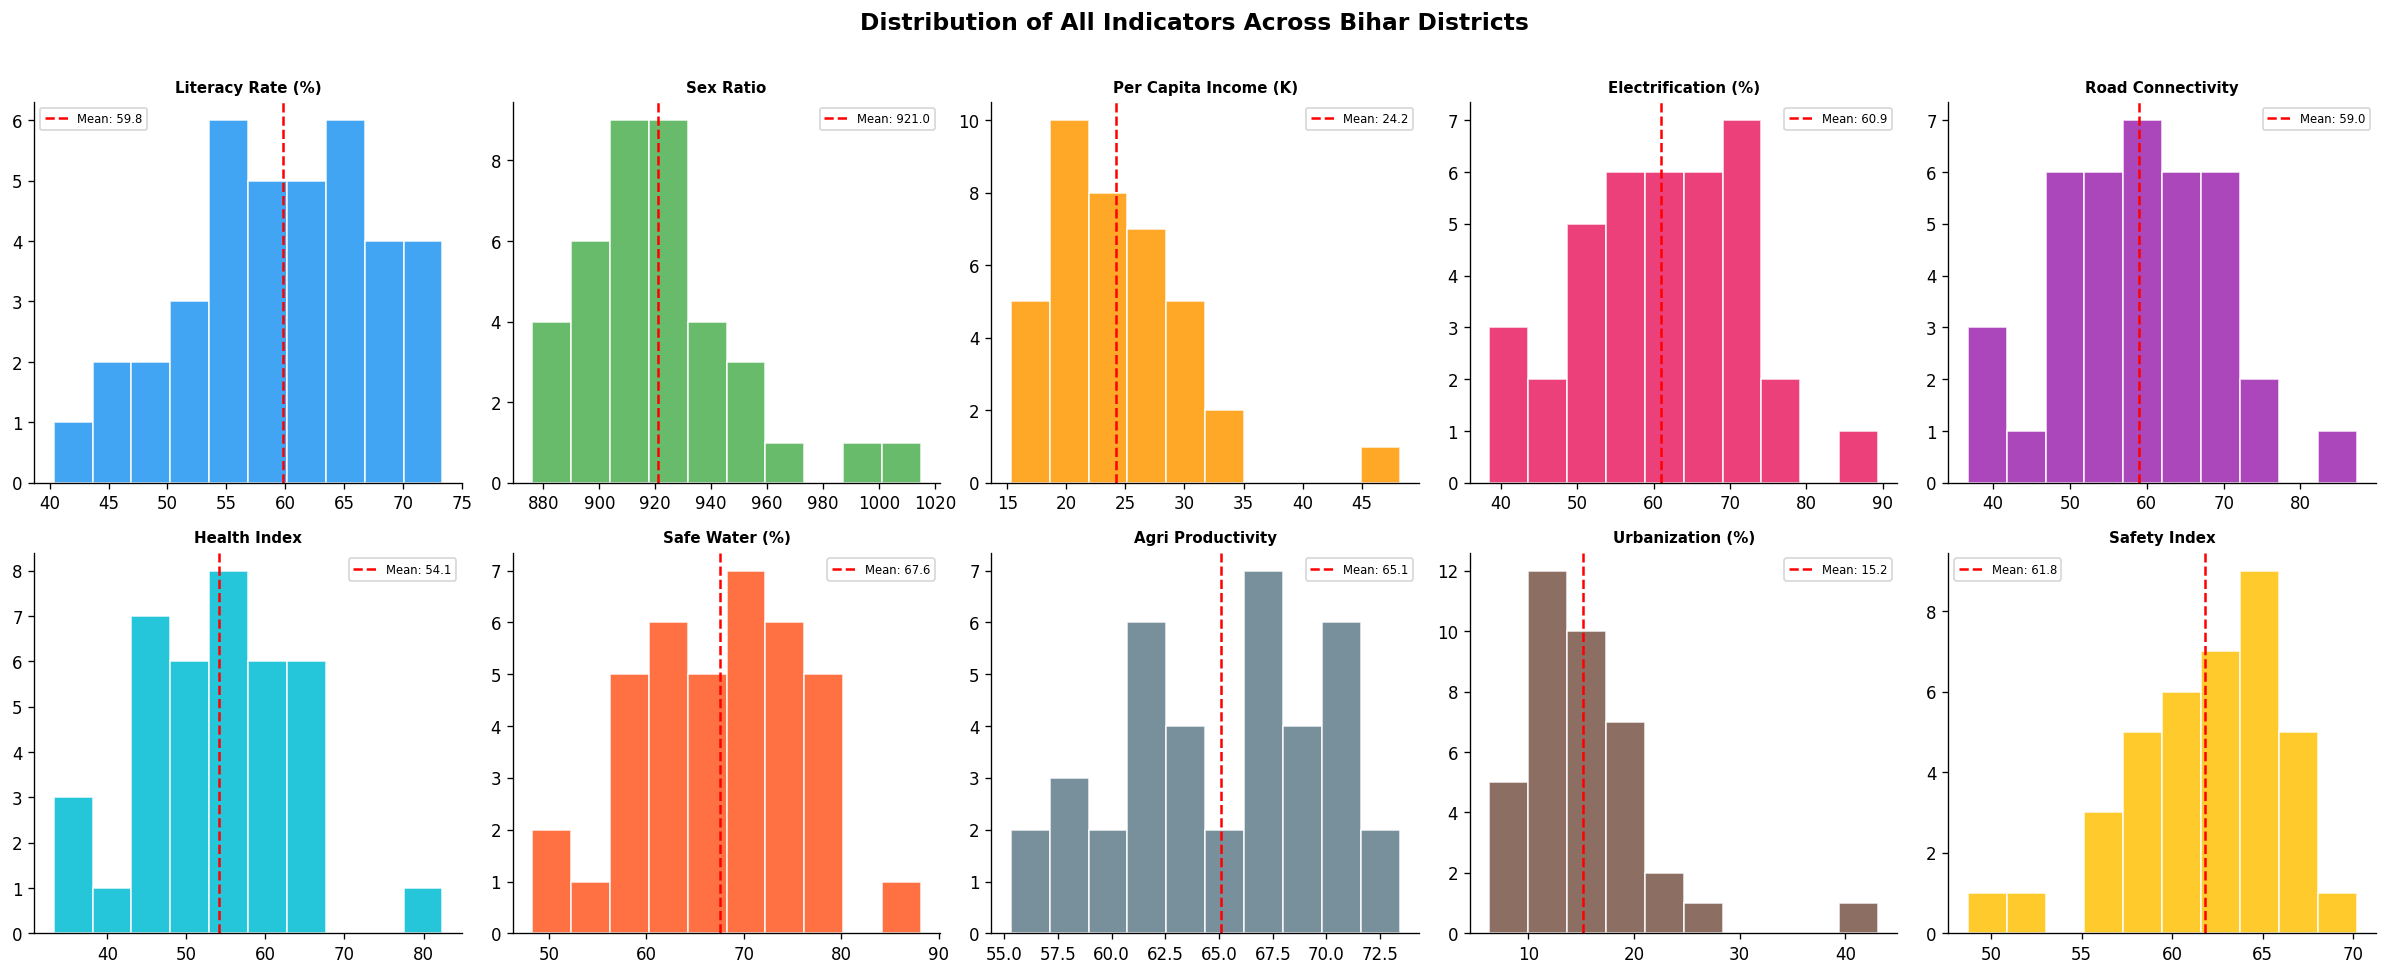

EDA plot saved!


In [5]:
# Distribution plots for all indicators
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Distribution of All Indicators Across Bihar Districts', fontsize=14, fontweight='bold', y=1.01)

colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0',
          '#00BCD4','#FF5722','#607D8B','#795548','#FFC107']

label_map = {
    'Literacy_Rate': 'Literacy Rate (%)',
    'Sex_Ratio': 'Sex Ratio',
    'Per_Capita_Income_K': 'Per Capita Income (K)',
    'Electrification_Pct': 'Electrification (%)',
    'Road_Connectivity': 'Road Connectivity',
    'Health_Index': 'Health Index',
    'Safe_Water_Pct': 'Safe Water (%)',
    'Agri_Productivity': 'Agri Productivity',
    'Urbanization_Pct': 'Urbanization (%)',
    'Safety_Index': 'Safety Index'
}

for ax, ind, color in zip(axes.flatten(), INDICATORS, colors):
    ax.hist(df[ind], bins=10, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[ind].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[ind].mean():.1f}')
    ax.set_title(label_map[ind], fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('EDA plot saved!')

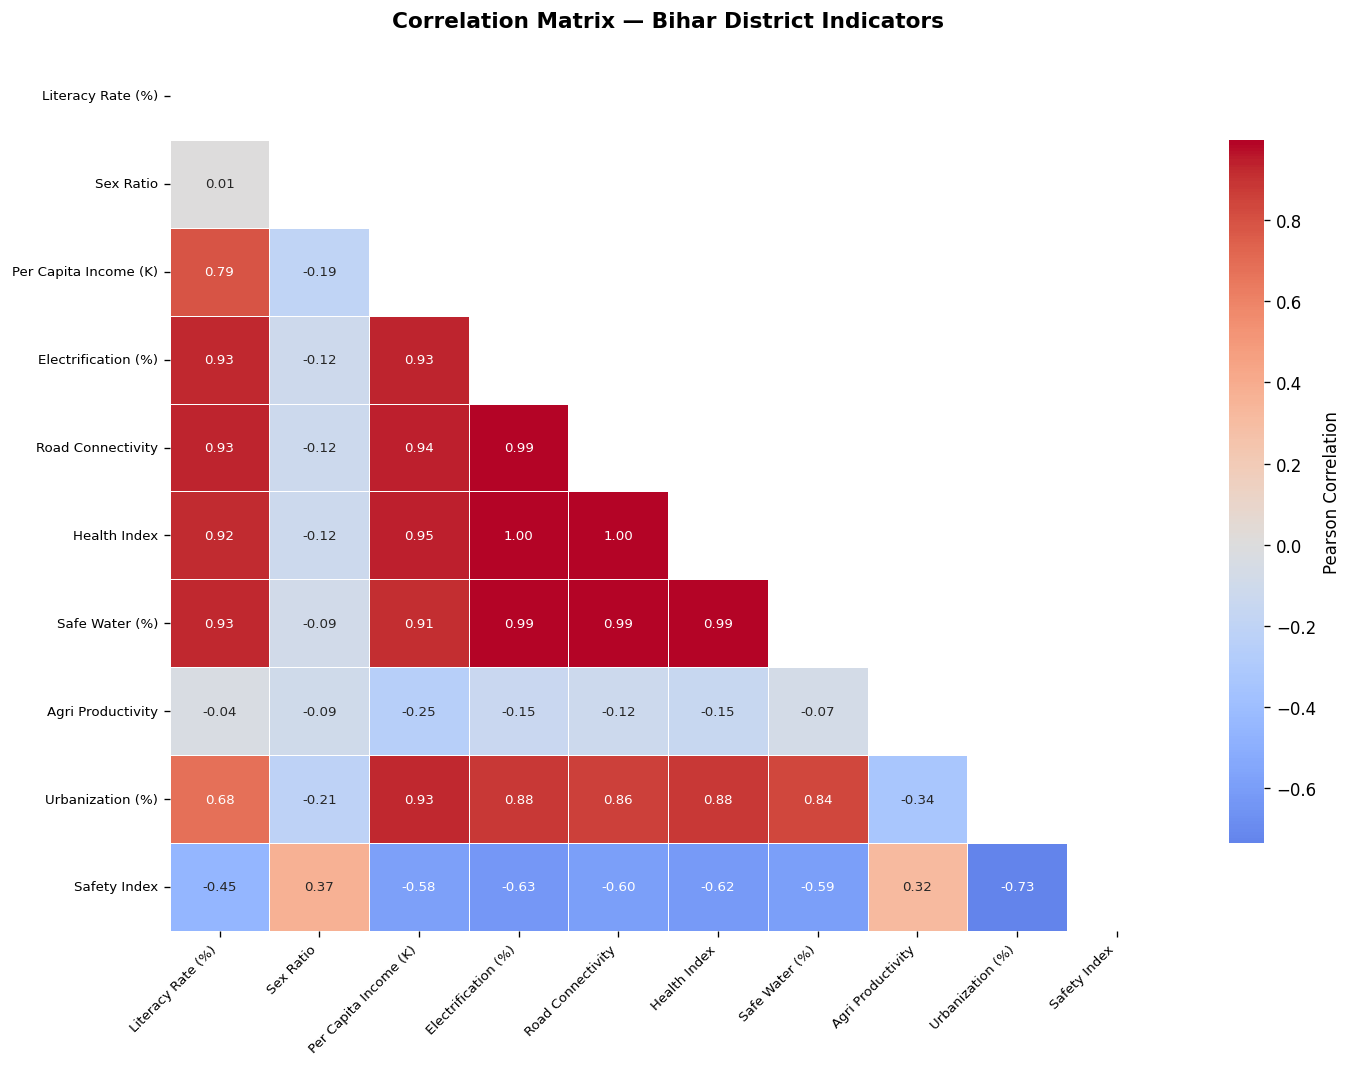

Correlation heatmap saved!


In [6]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[INDICATORS].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
            annot_kws={'size': 8})

ax.set_title('Correlation Matrix — Bihar District Indicators', fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels([label_map[c] for c in corr.columns], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([label_map[c] for c in corr.index], rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Correlation heatmap saved!')

---
## ⚙️ Step 3: Compute BDDI Score
**Method:** Weighted Composite Index after Min-Max Normalisation

In [7]:
# Weights (must sum to 1.0)
WEIGHTS = {
    'Literacy_Rate':         0.14,
    'Per_Capita_Income_K':   0.15,
    'Health_Index':          0.13,
    'Electrification_Pct':   0.11,
    'Road_Connectivity':     0.10,
    'Safe_Water_Pct':        0.10,
    'Agri_Productivity':     0.09,
    'Sex_Ratio':             0.07,
    'Urbanization_Pct':      0.07,
    'Safety_Index':          0.04,
}
print(f'Weight sum check: {sum(WEIGHTS.values())} (should be 1.0)')

# Min-Max Normalisation
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[INDICATORS] = scaler.fit_transform(df[INDICATORS])

# Weighted BDDI Score
df['BDDI_Score'] = sum(df_norm[ind] * WEIGHTS[ind] for ind in INDICATORS) * 100
df['BDDI_Score'] = df['BDDI_Score'].round(2)
df['Rank'] = df['BDDI_Score'].rank(ascending=False).astype(int)
df = df.sort_values('Rank').reset_index(drop=True)

# Development Category
def categorize(score):
    if score >= 65:   return 'Highly Developed'
    elif score >= 55: return 'Developed'
    elif score >= 45: return 'Moderately Developed'
    elif score >= 35: return 'Underdeveloped'
    else:             return 'Critically Underdeveloped'

df['Development_Category'] = df['BDDI_Score'].apply(categorize)

print(f'\nState Average BDDI Score: {df["BDDI_Score"].mean():.2f}')
print(f'Highest: {df.iloc[0]["District"]} ({df.iloc[0]["BDDI_Score"]})')
print(f'Lowest:  {df.iloc[-1]["District"]} ({df.iloc[-1]["BDDI_Score"]})')

print('\nCategory Distribution:')
print(df['Development_Category'].value_counts())

Weight sum check: 1.0 (should be 1.0)

State Average BDDI Score: 43.16
Highest: Patna (80.59)
Lowest:  Araria (10.84)

Category Distribution:
Development_Category
Critically Underdeveloped    13
Developed                    10
Moderately Developed          7
Underdeveloped                7
Highly Developed              1
Name: count, dtype: int64


In [8]:
# Final Ranked Table
df[['Rank','District','Region','BDDI_Score','Development_Category']].style\
    .background_gradient(subset=['BDDI_Score'], cmap='RdYlGn')\
    .set_caption('Bihar District Development Index — All 38 Districts')

,Rank,District,Region,BDDI_Score,Development_Category
0,1,Patna,Central Bihar,80.590000,Highly Developed
1,2,Rohtas,South Bihar,63.820000,Developed
2,3,Kaimur,South Bihar,61.150000,Developed
3,4,Begusarai,East Bihar,60.820000,Developed
4,5,Siwan,North Bihar,60.170000,Developed
5,6,Buxar,South Bihar,59.950000,Developed
6,7,Bhojpur,South Bihar,59.850000,Developed
7,8,Nalanda,South Bihar,58.300000,Developed
8,9,Vaishali,North Bihar,56.780000,Developed
9,10,Saran,North Bihar,56.250000,Developed


---
## 🤖 Step 4: K-Means Clustering
Group districts into development clusters using unsupervised machine learning.

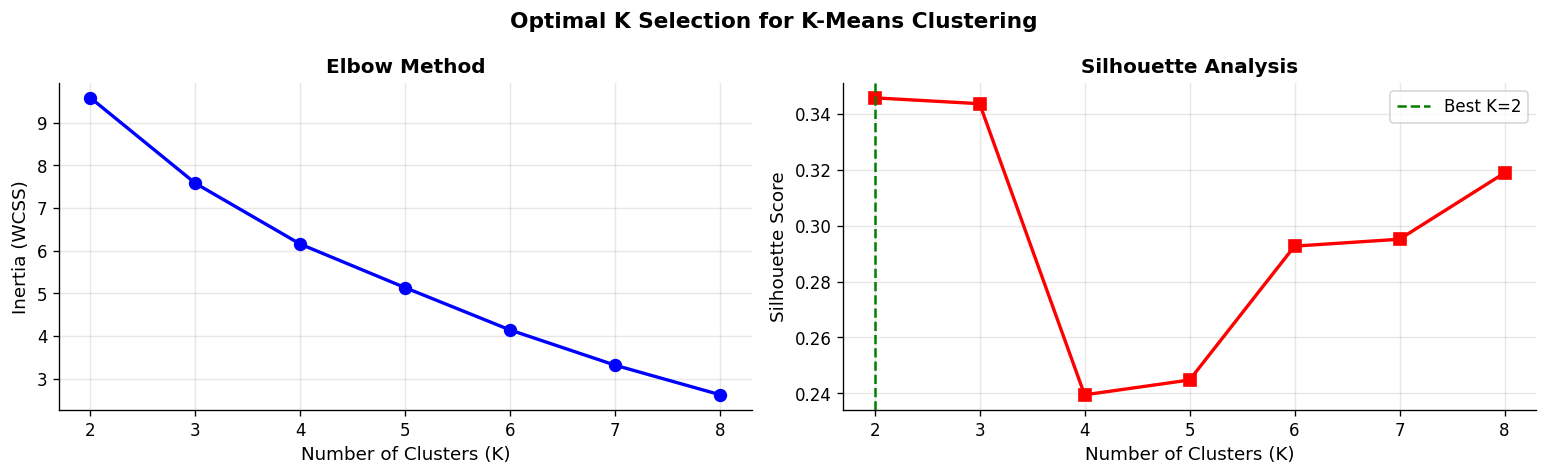

Best K by silhouette: 2 (score=0.346)


In [9]:
X = df_norm[INDICATORS].values

# ── Elbow Method ──
inertias = []
silhouette_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Clusters (K)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

ax2.plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=7)
best_k = list(K_range)[np.argmax(silhouette_scores)]
ax2.axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.suptitle('Optimal K Selection for K-Means Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_optimal_k.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Best K by silhouette: {best_k} (score={max(silhouette_scores):.3f})')

In [10]:
# Apply K-Means with K=4
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)

# Label clusters by average BDDI score (1=highest, 4=lowest)
cluster_avg = df.groupby('Cluster')['BDDI_Score'].mean().sort_values(ascending=False)
cluster_label_map = {cid: rank+1 for rank, cid in enumerate(cluster_avg.index)}
df['Cluster_Label'] = df['Cluster'].map(cluster_label_map)

cluster_names = {
    1: 'Cluster 1: Advanced',
    2: 'Cluster 2: Progressing',
    3: 'Cluster 3: Lagging',
    4: 'Cluster 4: Vulnerable'
}
df['Cluster_Name'] = df['Cluster_Label'].map(cluster_names)

print('Districts per cluster:')
for cid, cname in cluster_names.items():
    districts = df[df['Cluster_Label']==cid]['District'].tolist()
    avg = df[df['Cluster_Label']==cid]['BDDI_Score'].mean()
    print(f'\n{cname} (Avg BDDI: {avg:.1f})')
    print(f'  {districts}')

Districts per cluster:

Cluster 1: Advanced (Avg BDDI: 80.6)
  ['Patna']

Cluster 2: Progressing (Avg BDDI: 47.3)
  ['Siwan', 'Buxar', 'Bhojpur', 'Nalanda', 'Vaishali', 'Saran', 'Gopalganj', 'Munger', 'Bhagalpur', 'Samastipur', 'Muzaffarpur', 'Jehanabad', 'Sitamarhi', 'Madhepura', 'Araria']

Cluster 3: Lagging (Avg BDDI: 40.5)
  ['Rohtas', 'Kaimur', 'Begusarai', 'East Champaran', 'Nawada', 'Saharsa', 'Katihar', 'Supaul', 'Banka', 'Jamui', 'Sheohar']

Cluster 4: Vulnerable (Avg BDDI: 36.9)
  ['Lakhisarai', 'Gaya', 'Sheikhpura', 'West Champaran', 'Aurangabad', 'Arwal', 'Darbhanga', 'Purnia', 'Khagaria', 'Madhubani', 'Kishanganj']


---
## 📉 Step 5: PCA — Dimensionality Reduction for Visualization

In [11]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
print(f'PCA Component 1: {var1:.1f}% variance explained')
print(f'PCA Component 2: {var2:.1f}% variance explained')
print(f'Total: {var1+var2:.1f}% variance explained')

# PCA Component Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=[label_map[i] for i in INDICATORS],
    columns=['PC1', 'PC2']
).round(3)

print('\nPCA Loadings (top contributors):')
print(loadings.sort_values('PC1', key=abs, ascending=False))

PCA Component 1: 65.8% variance explained
PCA Component 2: 16.7% variance explained
Total: 82.5% variance explained

PCA Loadings (top contributors):
                         PC1    PC2
Literacy Rate (%)      0.404  0.190
Safe Water (%)         0.391  0.121
Electrification (%)    0.381  0.060
Road Connectivity      0.376  0.081
Health Index           0.365  0.054
Per Capita Income (K)  0.315 -0.031
Urbanization (%)       0.286 -0.121
Safety Index          -0.262  0.217
Agri Productivity     -0.106  0.933
Sex Ratio             -0.059 -0.044


---
## 📊 Step 6: Visualizations

In [12]:
# ─── COLOR PALETTE ───
CAT_COLORS = {
    'Highly Developed':          '#1a9850',
    'Developed':                 '#91cf60',
    'Moderately Developed':      '#fee08b',
    'Underdeveloped':            '#fc8d59',
    'Critically Underdeveloped': '#d73027',
}
CLUSTER_COLORS = {1: '#2166ac', 2: '#74add1', 3: '#f46d43', 4: '#a50026'}
REGION_COLORS  = {'Central Bihar': '#9467bd', 'South Bihar': '#2ca02c',
                  'North Bihar': '#1f77b4',   'East Bihar':  '#d62728'}

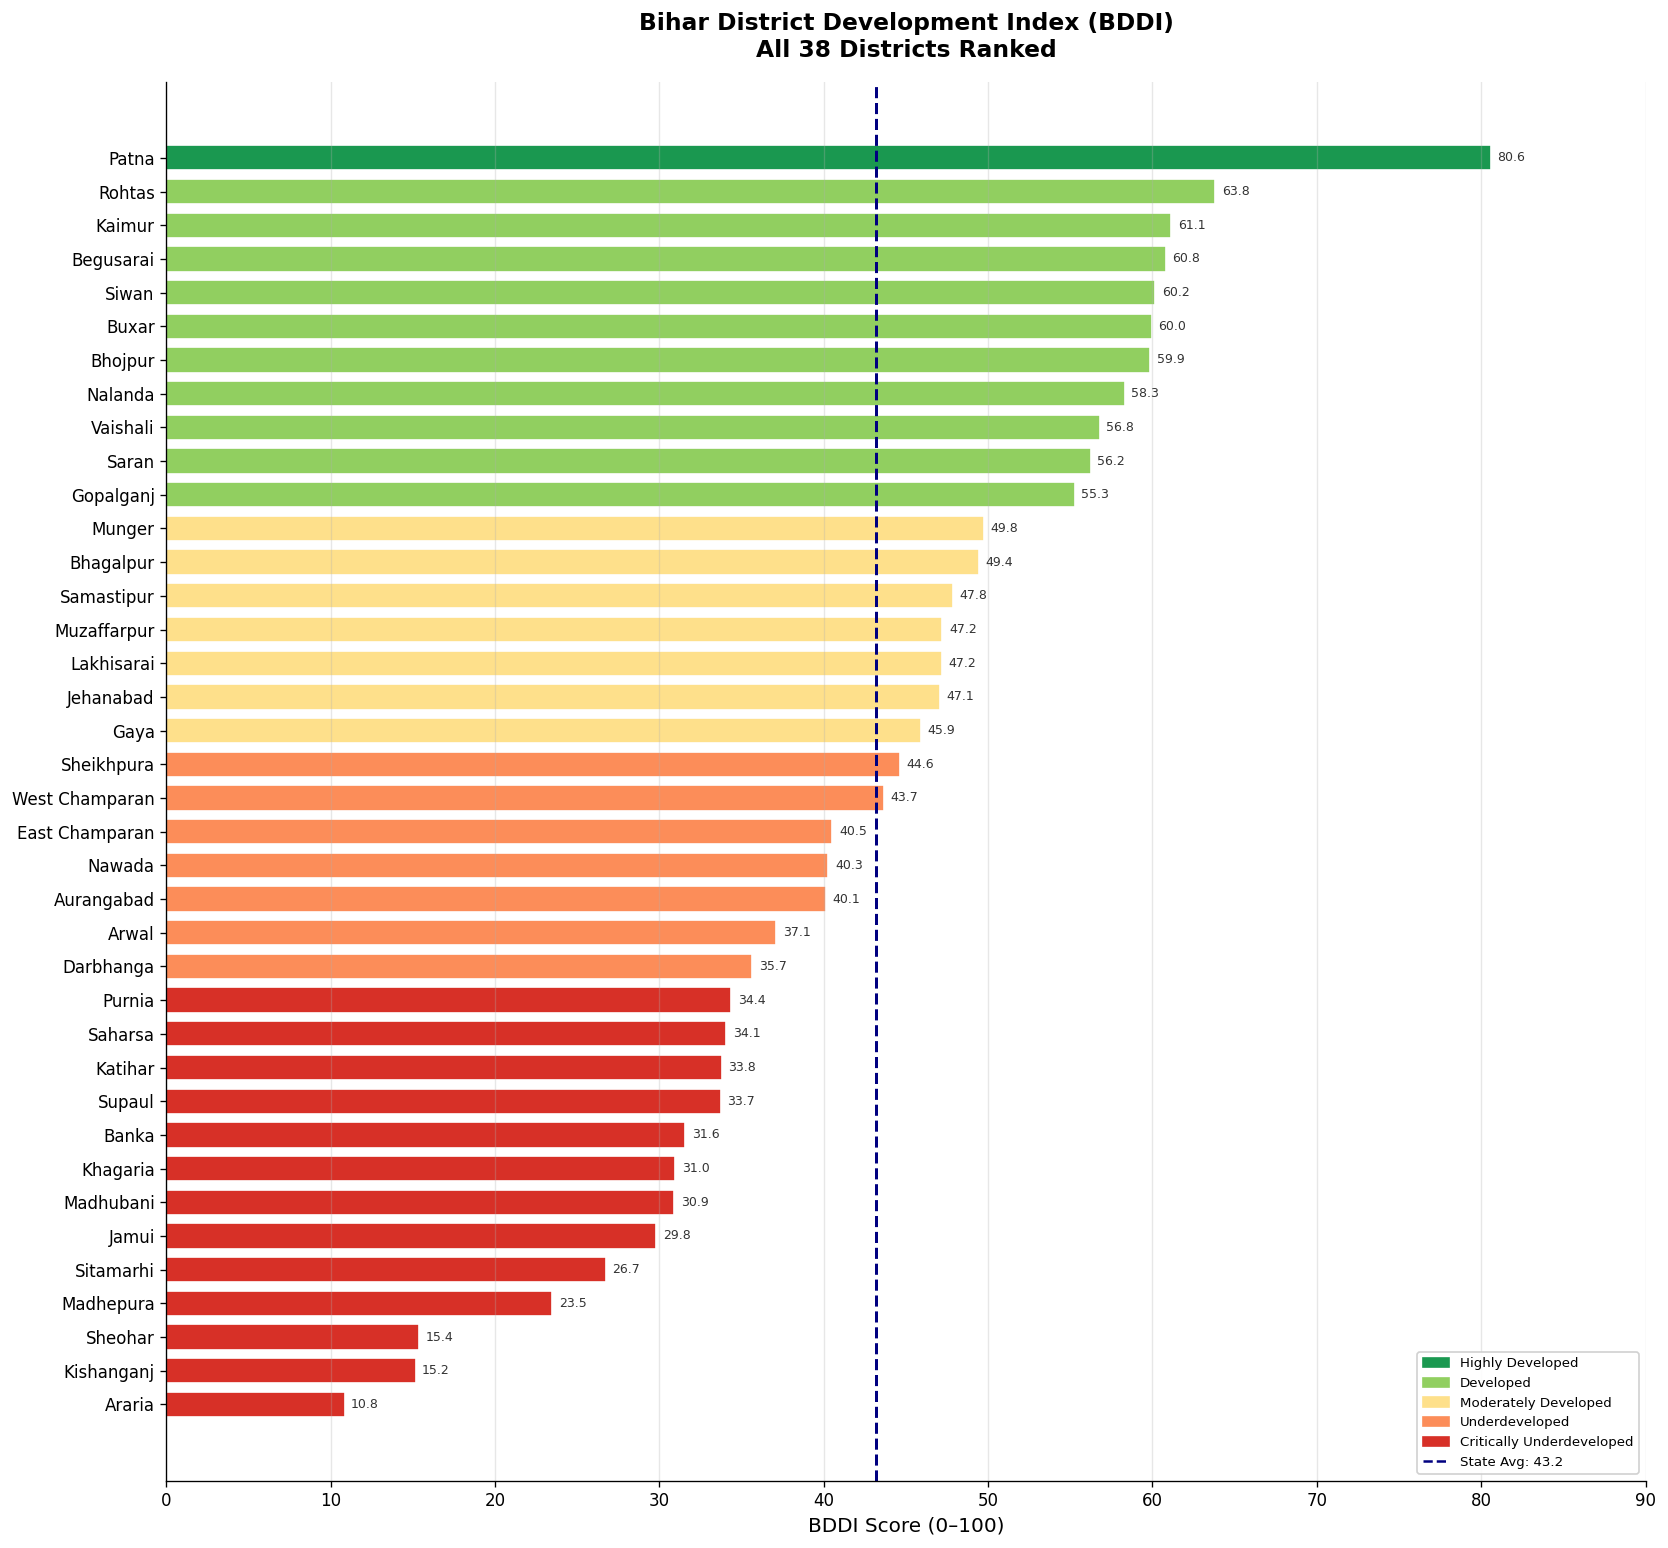

In [13]:
# ─── PLOT 1: RANKED BAR CHART ───
fig, ax = plt.subplots(figsize=(14, 13))
colors_bar = [CAT_COLORS[c] for c in df['Development_Category']]
bars = ax.barh(df['District'], df['BDDI_Score'], color=colors_bar, edgecolor='white', height=0.75)

ax.set_xlabel('BDDI Score (0–100)', fontsize=12)
ax.set_title('Bihar District Development Index (BDDI)\nAll 38 Districts Ranked',
             fontsize=14, fontweight='bold', pad=15)
avg = df['BDDI_Score'].mean()
ax.axvline(avg, color='navy', linestyle='--', linewidth=1.8, label=f'State Avg: {avg:.1f}')

for bar, score in zip(bars, df['BDDI_Score']):
    ax.text(score + 0.4, bar.get_y() + bar.get_height()/2, f'{score:.1f}',
            va='center', fontsize=7.5, color='#333')

patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
avg_line = plt.Line2D([0],[0], color='navy', linestyle='--', label=f'State Avg: {avg:.1f}')
ax.legend(handles=patches + [avg_line], loc='lower right', fontsize=8, framealpha=0.9)
ax.invert_yaxis()
ax.set_xlim(0, 90)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('plot1_ranked_bar.png', bbox_inches='tight', dpi=150)
plt.show()

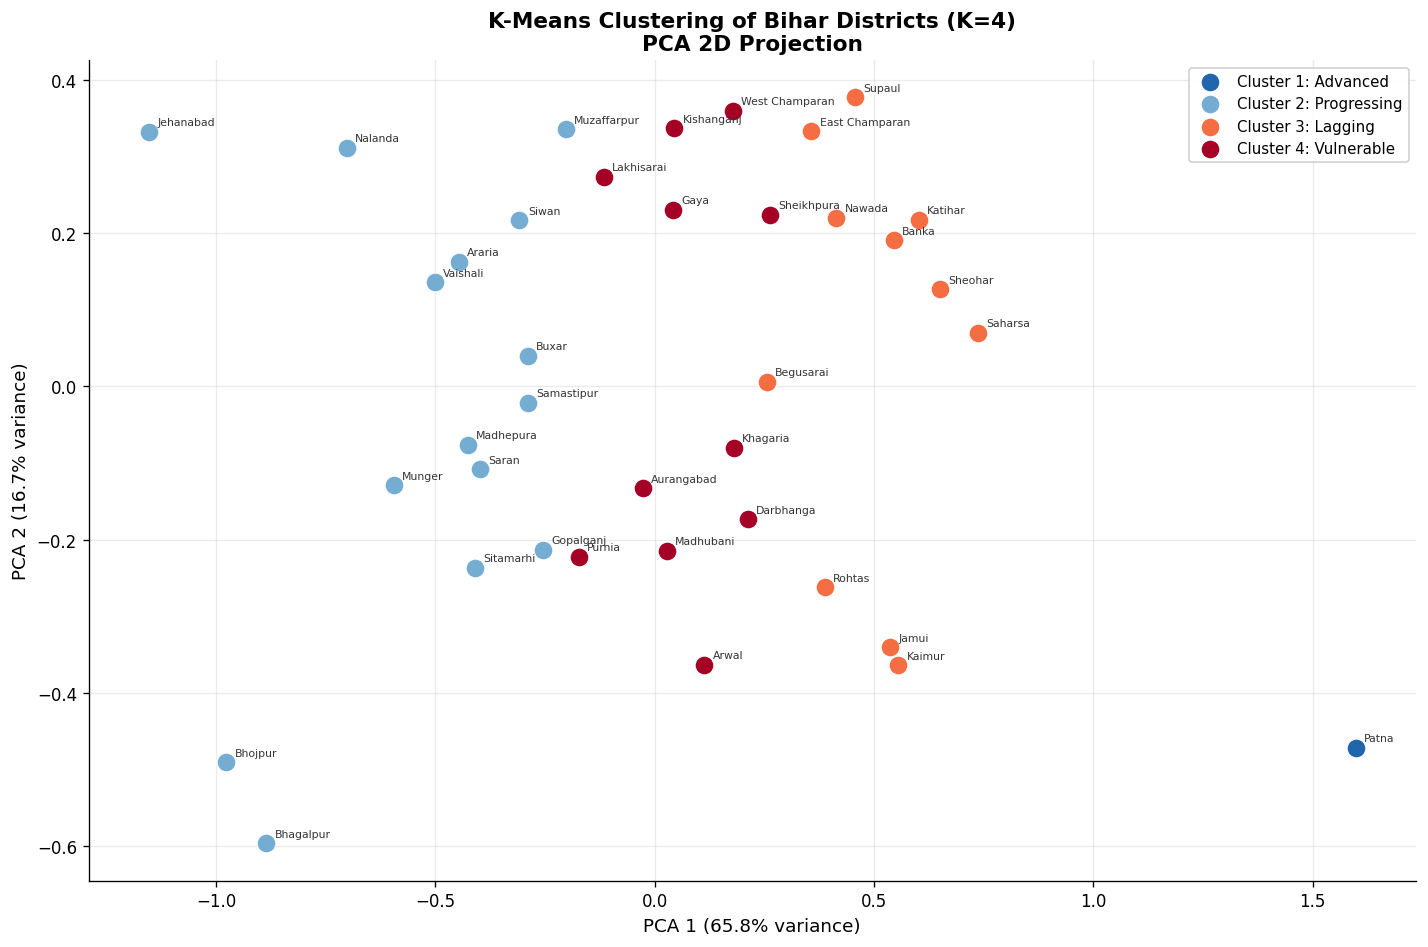

In [14]:
# ─── PLOT 2: CLUSTER SCATTER (PCA) ───
fig, ax = plt.subplots(figsize=(12, 8))

for cid, cname in cluster_names.items():
    mask = df['Cluster_Label'] == cid
    ax.scatter(df.loc[mask,'PCA1'], df.loc[mask,'PCA2'],
               color=CLUSTER_COLORS[cid], label=cname, s=130,
               edgecolors='white', linewidths=0.8, zorder=3)
    for _, row in df[mask].iterrows():
        ax.annotate(row['District'], (row['PCA1'], row['PCA2']),
                    textcoords='offset points', xytext=(5,4), fontsize=6.5, color='#333')

ax.set_xlabel(f'PCA 1 ({var1:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PCA 2 ({var2:.1f}% variance)', fontsize=11)
ax.set_title('K-Means Clustering of Bihar Districts (K=4)\nPCA 2D Projection',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('plot2_cluster_pca.png', bbox_inches='tight', dpi=150)
plt.show()

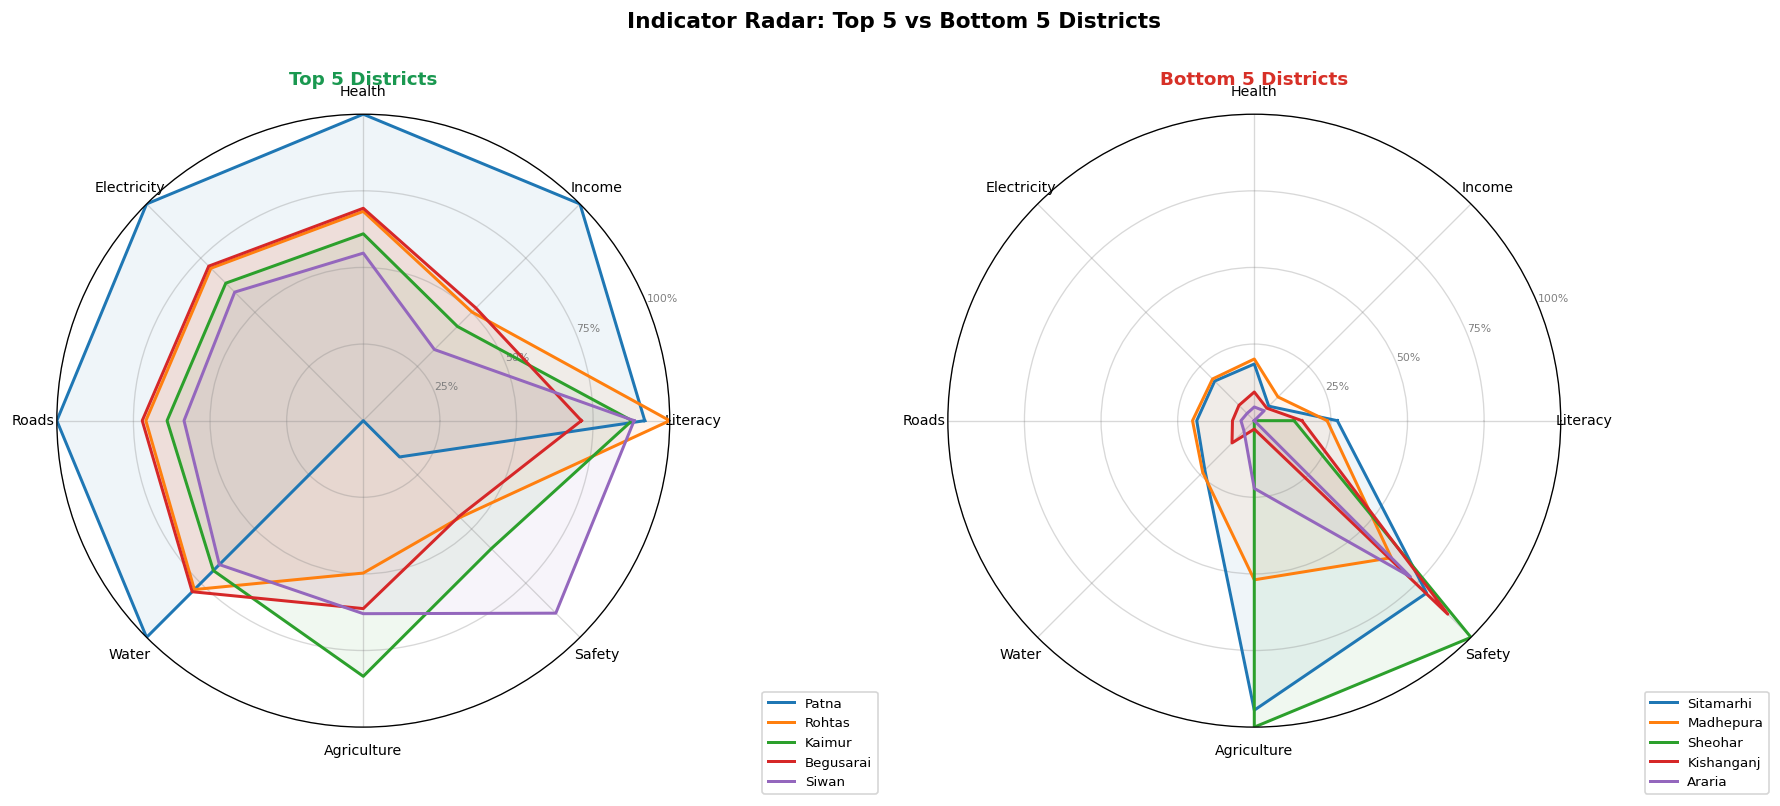

In [15]:
# ─── PLOT 3: RADAR CHART (Top 5 vs Bottom 5) ───
radar_indicators = ['Literacy_Rate','Per_Capita_Income_K','Health_Index',
                    'Electrification_Pct','Road_Connectivity','Safe_Water_Pct',
                    'Agri_Productivity','Safety_Index']
radar_labels = ['Literacy','Income','Health','Electricity','Roads','Water','Agriculture','Safety']

N = len(radar_labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

top5    = df.head(5)['District'].tolist()
bottom5 = df.tail(5)['District'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 7), subplot_kw=dict(polar=True))
fig.suptitle('Indicator Radar: Top 5 vs Bottom 5 Districts', fontsize=13, fontweight='bold')

for ax, group, title, color in [
    (axes[0], top5,    'Top 5 Districts',    '#1a9850'),
    (axes[1], bottom5, 'Bottom 5 Districts', '#d73027'),
]:
    ax.set_title(title, fontsize=11, fontweight='bold', pad=18, color=color)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=8.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=6.5, color='grey')
    ax.grid(color='grey', alpha=0.3)
    for dist in group:
        row = df_norm[df_norm['District'] == dist]
        vals = row[radar_indicators].values.flatten().tolist()
        vals += vals[:1]
        ax.plot(angles, vals, linewidth=1.8, label=dist)
        ax.fill(angles, vals, alpha=0.07)
    ax.legend(loc='lower right', bbox_to_anchor=(1.35, -0.12), fontsize=8)

plt.tight_layout()
plt.savefig('plot3_radar.png', bbox_inches='tight', dpi=150)
plt.show()

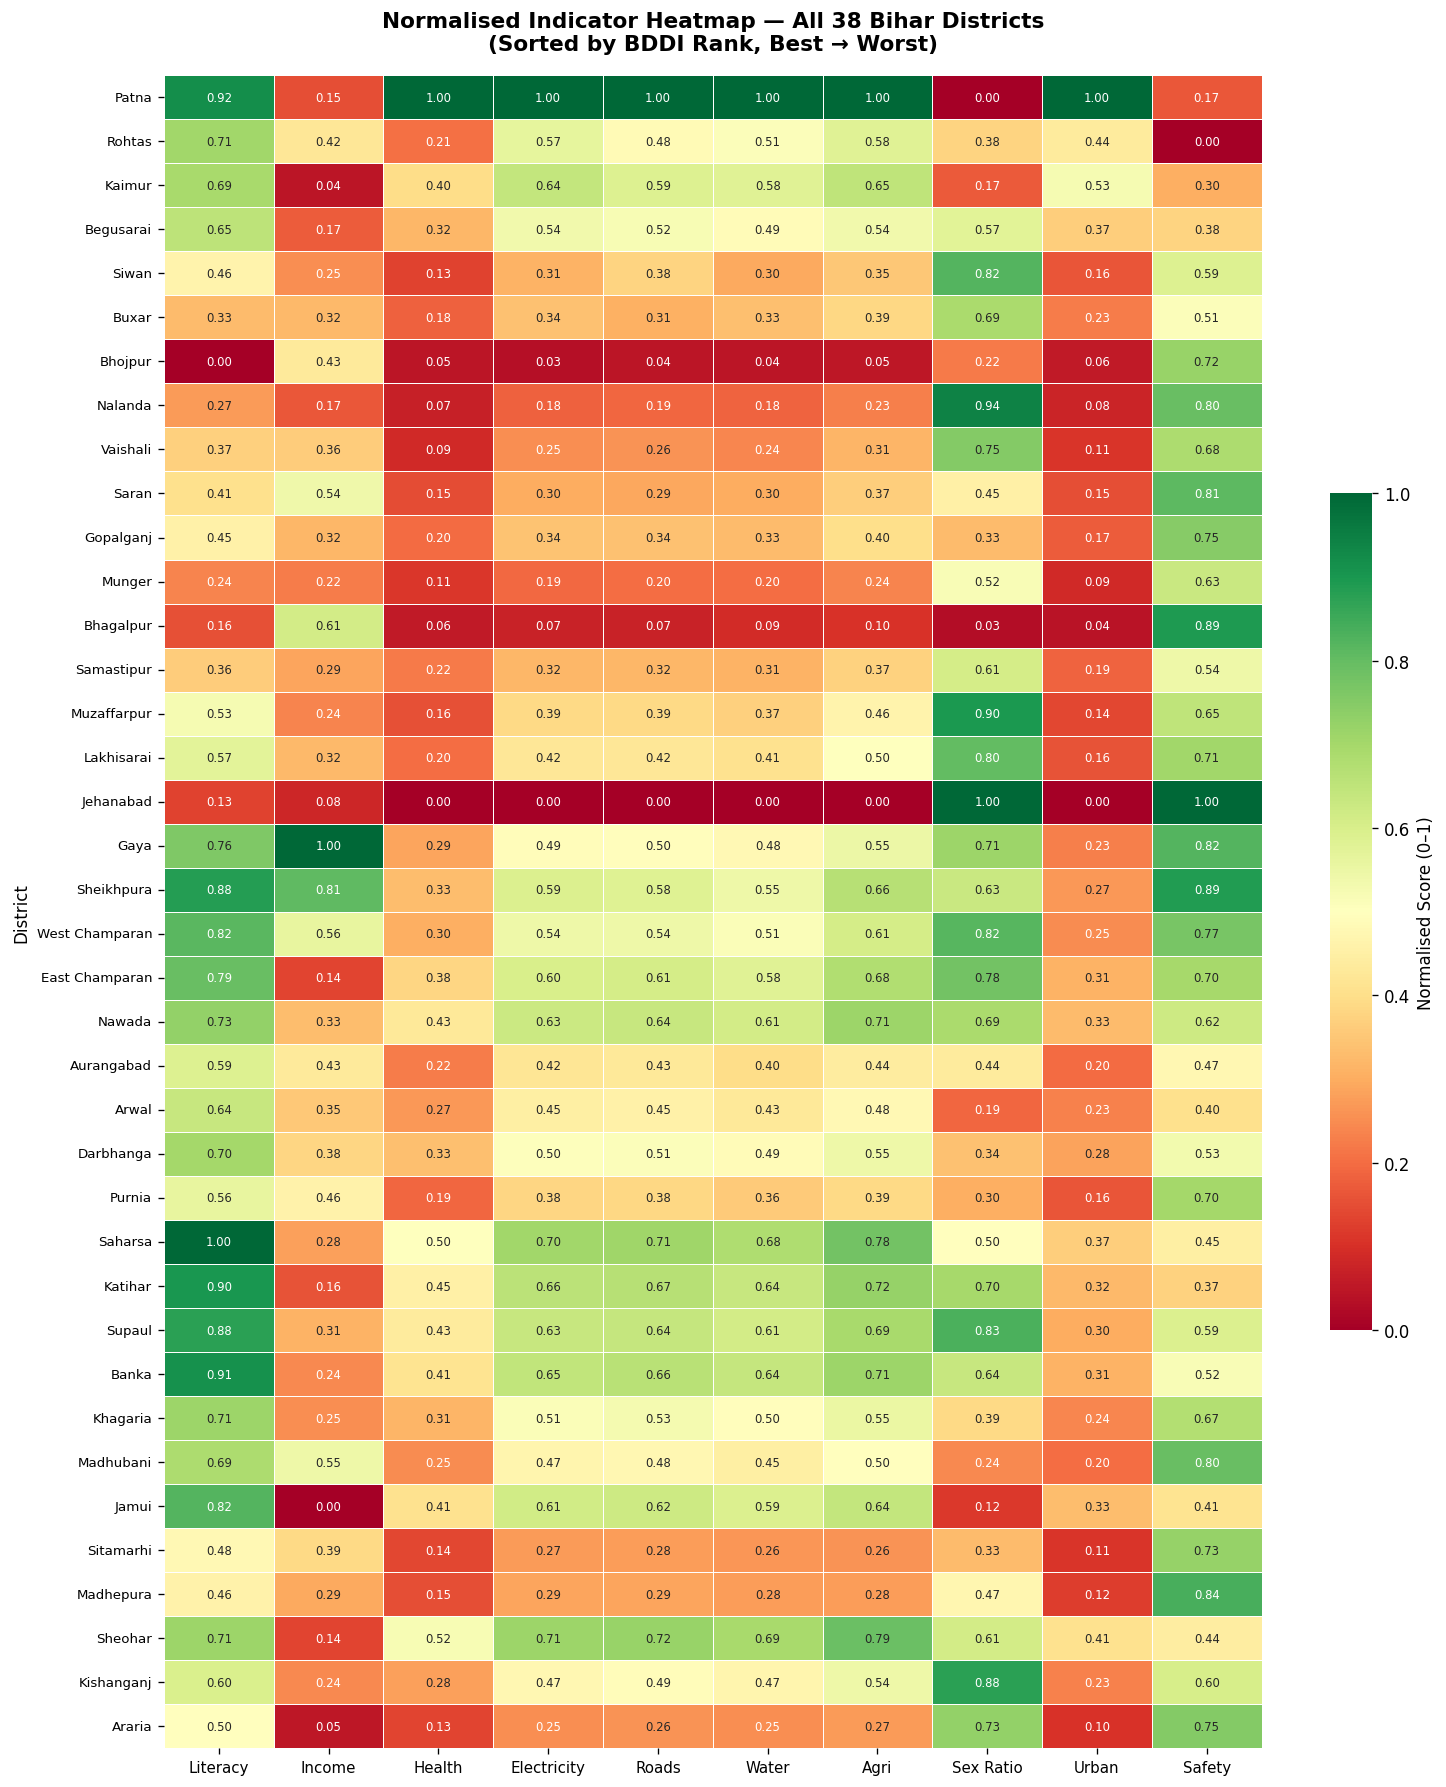

In [16]:
# ─── PLOT 4: NORMALISED INDICATOR HEATMAP ───
short_labels = ['Literacy','Income','Health','Electricity','Roads','Water','Agri','Sex Ratio','Urban','Safety']

heatmap_df = df_norm.set_index(df['District'])[INDICATORS].copy()
heatmap_df.columns = short_labels
heatmap_df = heatmap_df.loc[df['District']]

fig, ax = plt.subplots(figsize=(13, 15))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Normalised Score (0–1)', 'shrink': 0.5},
            annot_kws={'size': 7})
ax.set_title('Normalised Indicator Heatmap — All 38 Bihar Districts\n(Sorted by BDDI Rank, Best → Worst)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('plot4_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

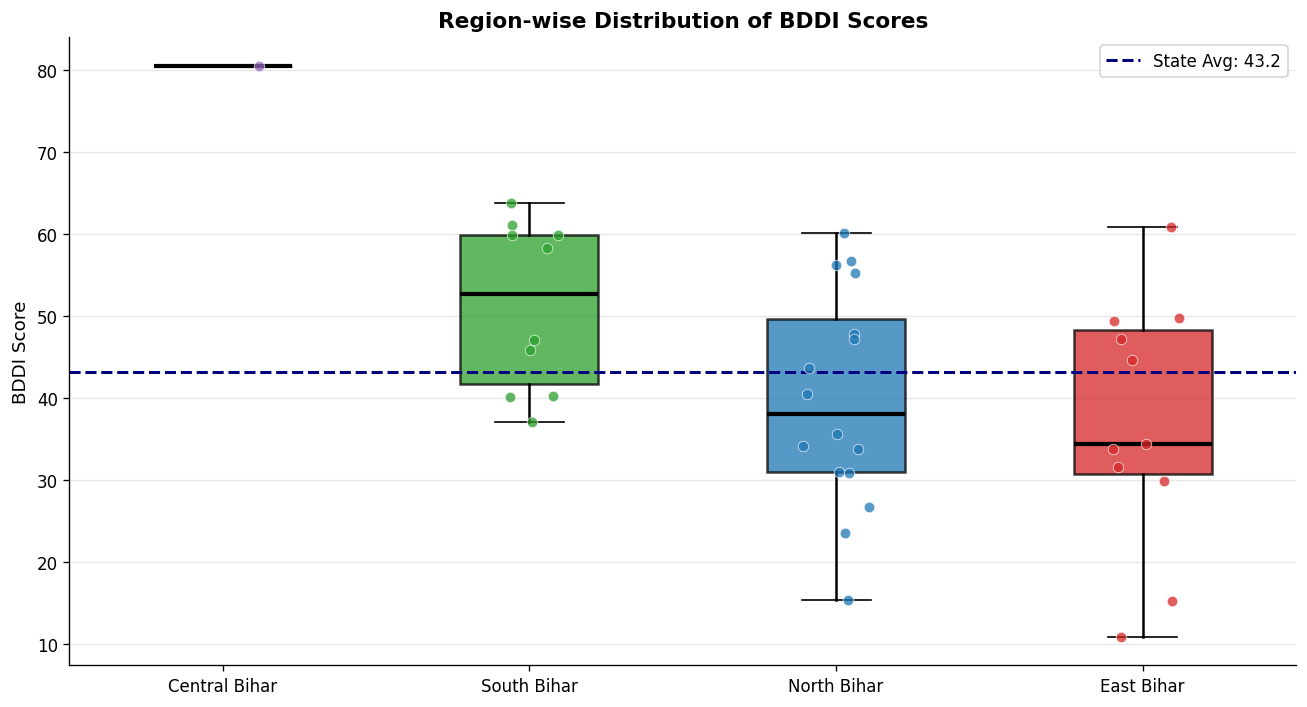

In [17]:
# ─── PLOT 5: REGION-WISE BOX PLOT ───
fig, ax = plt.subplots(figsize=(11, 6))
region_order = df.groupby('Region')['BDDI_Score'].median().sort_values(ascending=False).index.tolist()
data_by_region = [df[df['Region']==r]['BDDI_Score'].values for r in region_order]

bp = ax.boxplot(data_by_region, labels=region_order, patch_artist=True,
                medianprops=dict(color='black', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                boxprops=dict(linewidth=1.5))
for patch, r in zip(bp['boxes'], region_order):
    patch.set_facecolor(REGION_COLORS[r])
    patch.set_alpha(0.75)

# Overlay individual points (jitter)
for i, (r, vals) in enumerate(zip(region_order, data_by_region)):
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(i + 1 + jitter, vals, color=REGION_COLORS[r],
               alpha=0.75, s=40, zorder=3, edgecolors='white', linewidths=0.5)

ax.axhline(df['BDDI_Score'].mean(), color='navy', linestyle='--', linewidth=1.8,
           label=f'State Avg: {df["BDDI_Score"].mean():.1f}')
ax.set_ylabel('BDDI Score', fontsize=11)
ax.set_title('Region-wise Distribution of BDDI Scores', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot5_region_box.png', bbox_inches='tight', dpi=150)
plt.show()

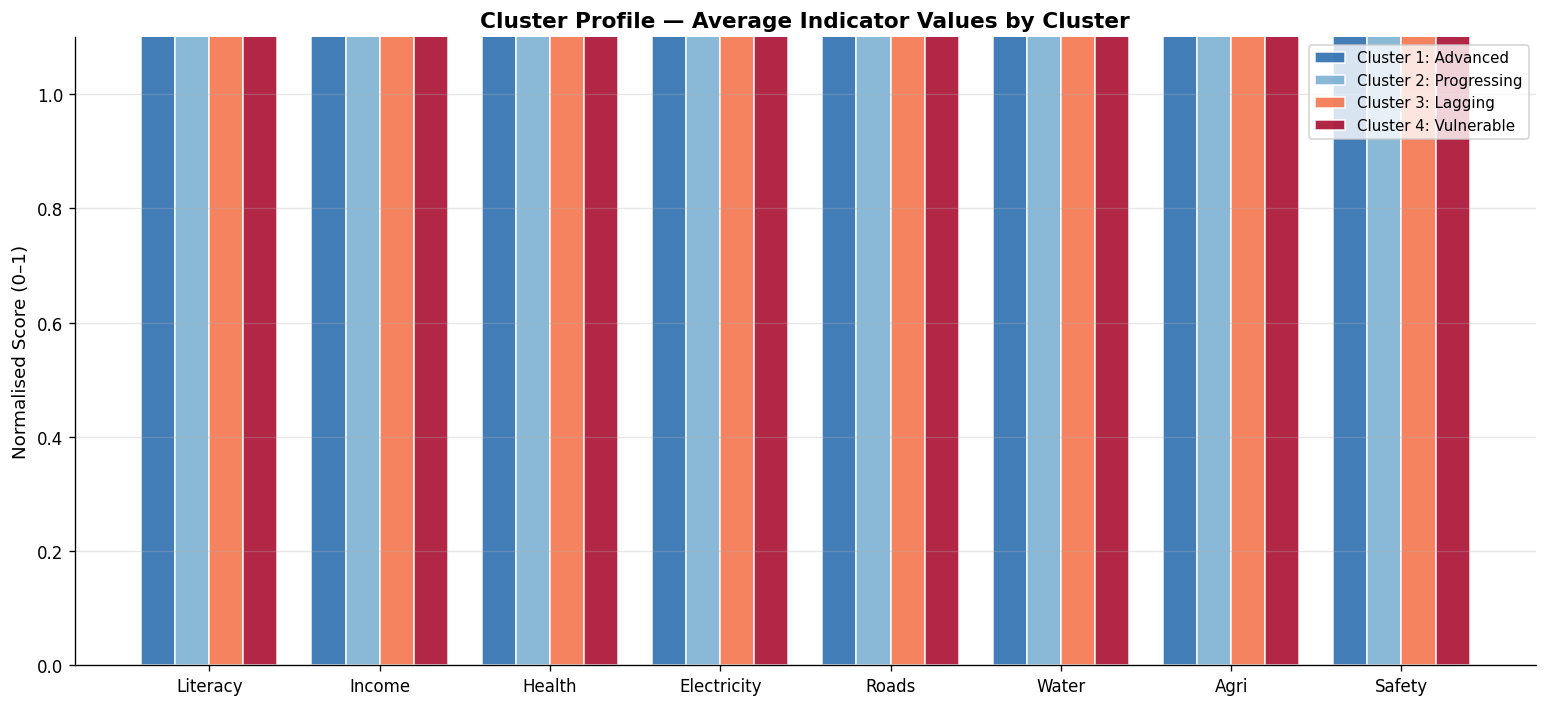

In [18]:
# ─── PLOT 6: CLUSTER PROFILE BAR CHART ───
cluster_profile = df.groupby('Cluster_Label')[radar_indicators].mean()
cluster_profile.index = [cluster_names[i] for i in cluster_profile.index]
cluster_profile.columns = ['Literacy','Income','Health','Electricity','Roads','Water','Agri','Safety']

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(cluster_profile.columns))
width = 0.2

for i, (cname, row) in enumerate(cluster_profile.iterrows()):
    ax.bar(x + i*width, row.values, width, label=cname,
           color=list(CLUSTER_COLORS.values())[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(cluster_profile.columns, fontsize=10)
ax.set_ylabel('Normalised Score (0–1)', fontsize=11)
ax.set_title('Cluster Profile — Average Indicator Values by Cluster', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot6_cluster_profile.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
# ─── PLOT 7: INTERACTIVE SCATTER (Plotly) ───
fig_plotly = px.scatter(
    df,
    x='PCA1', y='PCA2',
    color='Cluster_Name',
    size='BDDI_Score',
    hover_name='District',
    hover_data={
        'BDDI_Score': True,
        'Development_Category': True,
        'Region': True,
        'Rank': True,
        'PCA1': False, 'PCA2': False
    },
    title='Interactive K-Means Cluster Scatter — Bihar Districts (Hover for details)',
    color_discrete_sequence=['#2166ac','#74add1','#f46d43','#a50026'],
    labels={'PCA1': f'PCA 1 ({var1:.1f}% var)', 'PCA2': f'PCA 2 ({var2:.1f}% var)'}
)
fig_plotly.update_traces(marker=dict(line=dict(width=1, color='white')))
fig_plotly.update_layout(height=600, legend_title='Cluster')
fig_plotly.show()

# Save as HTML for portfolio
fig_plotly.write_html('plot7_interactive_scatter.html')
print('Interactive plot saved as HTML!')

Interactive plot saved as HTML!


In [20]:
# ─── PLOT 8: INTERACTIVE BAR (Plotly) ───
fig_bar = px.bar(
    df.sort_values('Rank'),
    x='BDDI_Score', y='District',
    orientation='h',
    color='Development_Category',
    color_discrete_map=CAT_COLORS,
    hover_data=['Rank','Region','Cluster_Name','Literacy_Rate','Per_Capita_Income_K','Health_Index'],
    title='Bihar District Development Index — Interactive Ranking',
    labels={'BDDI_Score': 'BDDI Score', 'District': ''}
)
fig_bar.add_vline(x=df['BDDI_Score'].mean(), line_dash='dash', line_color='navy',
                  annotation_text=f'State Avg: {df["BDDI_Score"].mean():.1f}',
                  annotation_position='top right')
fig_bar.update_layout(height=900, yaxis={'categoryorder':'total ascending'},
                      legend_title='Category')
fig_bar.show()

fig_bar.write_html('plot8_interactive_bar.html')
print('Interactive bar chart saved!')

Interactive bar chart saved!


---
## 💾 Step 7: Export Final Results

In [21]:
output_cols = ['Rank','District','Region','BDDI_Score','Development_Category',
               'Cluster_Name'] + INDICATORS
final_df = df[output_cols].copy()

# Save to CSV
final_df.to_csv('bihar_bddi_final_results.csv', index=False)
print('✅ CSV saved: bihar_bddi_final_results.csv')

# Preview
print(f'\nShape: {final_df.shape}')
final_df[['Rank','District','Region','BDDI_Score','Development_Category','Cluster_Name']].head(10)

✅ CSV saved: bihar_bddi_final_results.csv

Shape: (38, 16)


,Rank,District,Region,BDDI_Score,Development_Category,Cluster_Name
0,1,Patna,Central Bihar,80.59,Highly Developed,Cluster 1: Advanced
1,2,Rohtas,South Bihar,63.82,Developed,Cluster 3: Lagging
2,3,Kaimur,South Bihar,61.15,Developed,Cluster 3: Lagging
3,4,Begusarai,East Bihar,60.82,Developed,Cluster 3: Lagging
4,5,Siwan,North Bihar,60.17,Developed,Cluster 2: Progressing
5,6,Buxar,South Bihar,59.95,Developed,Cluster 2: Progressing
6,7,Bhojpur,South Bihar,59.85,Developed,Cluster 2: Progressing
7,8,Nalanda,South Bihar,58.30,Developed,Cluster 2: Progressing
8,9,Vaishali,North Bihar,56.78,Developed,Cluster 2: Progressing
9,10,Saran,North Bihar,56.25,Developed,Cluster 2: Progressing


In [22]:
# Download all saved files (in Colab)
from google.colab import files

saved_files = [
    'bihar_bddi_final_results.csv',
    'plot1_ranked_bar.png',
    'plot2_cluster_pca.png',
    'plot3_radar.png',
    'plot4_heatmap.png',
    'plot5_region_box.png',
    'plot6_cluster_profile.png',
    'plot7_interactive_scatter.html',
    'plot8_interactive_bar.html',
    'eda_distributions.png',
    'eda_correlation.png',
    'kmeans_optimal_k.png',
]

for f in saved_files:
    try:
        files.download(f)
        print(f'Downloaded: {f}')
    except Exception as e:
        print(f'Could not download {f}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: bihar_bddi_final_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: eda_correlation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: kmeans_optimal_k.png


---
## 🔑 Step 8: Key Findings & Policy Implications

In [23]:
print('=' * 65)
print('       BIHAR DISTRICT DEVELOPMENT INDEX — KEY FINDINGS')
print('=' * 65)

print(f'\n📊 State Average BDDI Score: {df["BDDI_Score"].mean():.2f} / 100')
print(f'📈 Highest: {df.iloc[0]["District"]} — {df.iloc[0]["BDDI_Score"]} ({df.iloc[0]["Development_Category"]})')
print(f'📉 Lowest:  {df.iloc[-1]["District"]} — {df.iloc[-1]["BDDI_Score"]} ({df.iloc[-1]["Development_Category"]})')
print(f'\n⚠️  Development Gap (Top-Bottom): {df.iloc[0]["BDDI_Score"] - df.iloc[-1]["BDDI_Score"]:.2f} points')

print('\n📌 Category Distribution:')
for cat, count in df['Development_Category'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * count
    print(f'  {cat:<30} {bar} ({count} districts, {pct:.0f}%)')

print('\n🗺️  Region-wise Average BDDI:')
region_summary = df.groupby('Region')['BDDI_Score'].agg(['mean','min','max','count'])
region_summary.columns = ['Avg Score','Min','Max','Districts']
print(region_summary.sort_values('Avg Score', ascending=False).round(2))

print('\n🤖 Cluster Summary:')
for cid, cname in cluster_names.items():
    grp = df[df['Cluster_Label']==cid]
    print(f'  {cname}: {len(grp)} districts | Avg BDDI: {grp["BDDI_Score"].mean():.1f}')

print('\n💡 Policy Recommendations:')
recs = [
    'Seemanchal (Araria, Kishanganj, Purnia, Katihar) → Priority health & education investment',
    'Sheohar & Madhepura → Targeted MGNREGS, PM Awas Yojana, electrification push',
    'North Bihar flood belt → Permanent rural road infrastructure under PMGSY',
    'South Bihar (Rohtas-Kaimur) → Scale agri-led model to adjacent underdeveloped districts',
    'State-level → Reduce Patna primacy; develop Muzaffarpur & Bhagalpur as secondary hubs',
]
for i, r in enumerate(recs, 1):
    print(f'  {i}. {r}')

print('\n✅ Analysis Complete!')

       BIHAR DISTRICT DEVELOPMENT INDEX — KEY FINDINGS

📊 State Average BDDI Score: 43.16 / 100
📈 Highest: Patna — 80.59 (Highly Developed)
📉 Lowest:  Araria — 10.84 (Critically Underdeveloped)

⚠️  Development Gap (Top-Bottom): 69.75 points

📌 Category Distribution:
  Critically Underdeveloped      █████████████ (13 districts, 34%)
  Developed                      ██████████ (10 districts, 26%)
  Moderately Developed           ███████ (7 districts, 18%)
  Underdeveloped                 ███████ (7 districts, 18%)
  Highly Developed               █ (1 districts, 3%)

🗺️  Region-wise Average BDDI:
               Avg Score    Min    Max  Districts
Region                                           
Central Bihar      80.59  80.59  80.59          1
South Bihar        51.36  37.12  63.82         10
North Bihar        39.92  15.37  60.17         16
East Bihar         37.03  10.84  60.82         11

🤖 Cluster Summary:
  Cluster 1: Advanced: 1 districts | Avg BDDI: 80.6
  Cluster 2: Progressing:

---
## 🚀 Future Scope

1. **Real Data Integration** — NFHS-5 district data, SECC 2011, UDISE school metrics
2. **Time Series Analysis** — Compare BDDI 2001 vs 2011 vs 2021 trajectory
3. **Spatial Autocorrelation** — Moran's I using district shapefiles (geopandas + libpysal)
4. **Power BI Dashboard** — Embed ML predictions via REST API into interactive dashboard
5. **Predictive Model** — Predict future BDDI from satellite data (nighttime lights VIIRS, NDVI)
6. **Regression Analysis** — Which single indicator most drives overall development?

---
## 🛠️ Tech Stack
```
Python 3.x
├── pandas           Data wrangling & aggregation
├── numpy            Numerical operations
├── scikit-learn     KMeans, PCA, MinMaxScaler, silhouette_score
├── matplotlib       Static visualizations
├── seaborn          Heatmap & distribution plots
└── plotly           Interactive charts & HTML exports
```

---
*Project by Rohitashv | RVCE Bengaluru | Data Analytics Portfolio*